In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
import os

print("Current Working Directory:")
print(os.getcwd())

Current Working Directory:
c:\Users\LAKSHMI PRIYA S\OneDrive\Desktop\intern DA\apex-data-analyst\notebooks


In [3]:
import os

print("Files in data/raw:")
print(os.listdir("../data/raw"))

print("\nFiles in data/processed:")
print(os.listdir("../data/processed"))

Files in data/raw:
['SuperMarket Analysis.csv']

Files in data/processed:
['city_sales.csv', 'cleaned_supermarket_sales.csv']


In [4]:
import pandas as pd

df = pd.read_csv("../data/processed/cleaned_supermarket_sales.csv")

print("Dataset loaded successfully!")
df.head()

Dataset loaded successfully!


,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Sales,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,Alex,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,1:08:00 PM,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,Giza,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29:00 AM,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,Alex,Yangon,Normal,Female,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,1:23:00 PM,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,Alex,Yangon,Member,Female,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,8:33:00 PM,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,Alex,Yangon,Member,Female,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37:00 AM,Ewallet,604.17,4.761905,30.2085,5.3


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Invoice ID               1000 non-null   str    
 1   Branch                   1000 non-null   str    
 2   City                     1000 non-null   str    
 3   Customer type            1000 non-null   str    
 4   Gender                   1000 non-null   str    
 5   Product line             1000 non-null   str    
 6   Unit price               1000 non-null   float64
 7   Quantity                 1000 non-null   int64  
 8   Tax 5%                   1000 non-null   float64
 9   Sales                    1000 non-null   float64
 10  Date                     1000 non-null   str    
 11  Time                     1000 non-null   str    
 12  Payment                  1000 non-null   str    
 13  cogs                     1000 non-null   float64
 14  gross margin percentage  1000 non-nu

In [6]:
df.columns


Index(['Invoice ID', 'Branch', 'City', 'Customer type', 'Gender',
       'Product line', 'Unit price', 'Quantity', 'Tax 5%', 'Sales', 'Date',
       'Time', 'Payment', 'cogs', 'gross margin percentage', 'gross income',
       'Rating'],
      dtype='str')

In [7]:
df["Date"] = pd.to_datetime(df["Date"])
df["Month"] = df["Date"].dt.month_name()

df[["Date", "Month"]].head()

,Date,Month
0,2019-01-05,January
1,2019-03-08,March
2,2019-03-03,March
3,2019-01-27,January
4,2019-02-08,February


In [8]:
df["Date"] = pd.to_datetime(df["Date"])

df["Month"] = df["Date"].dt.month_name()

df[["Date", "Month"]].head()

,Date,Month
0,2019-01-05,January
1,2019-03-08,March
2,2019-03-03,March
3,2019-01-27,January
4,2019-02-08,February


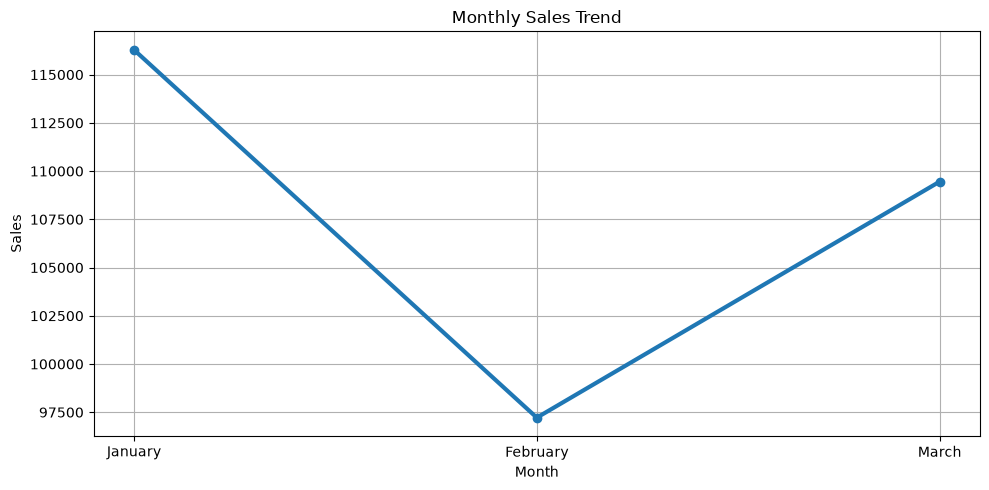

In [9]:
monthly_sales = df.groupby("Month")["Sales"].sum()

# Arrange months in calendar order
month_order = [
    "January", "February", "March", "April",
    "May", "June", "July", "August",
    "September", "October", "November", "December"
]

monthly_sales = monthly_sales.reindex(month_order).dropna()

plt.figure(figsize=(10,5))

plt.plot(monthly_sales.index,
         monthly_sales.values,
         marker="o",
         linewidth=3)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")

plt.grid(True)

plt.tight_layout()

plt.savefig("../visualization/monthly_sales.png")

plt.show()

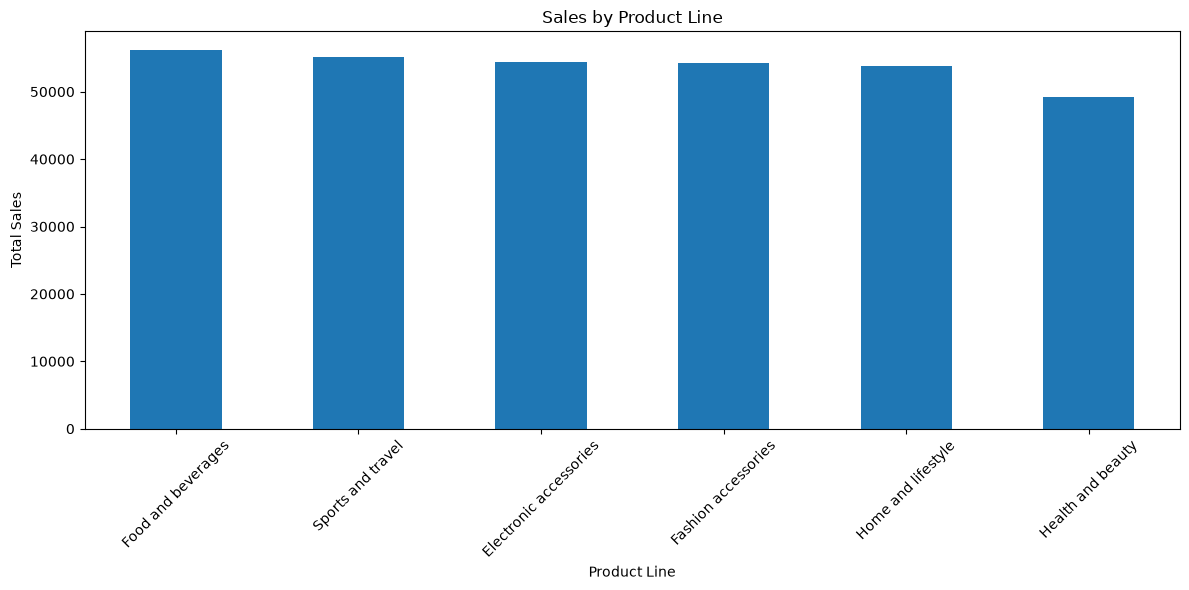

In [10]:
plt.figure(figsize=(12,6))

product_sales = df.groupby("Product line")["Sales"].sum().sort_values(ascending=False)

product_sales.plot(kind="bar")

plt.title("Sales by Product Line")
plt.xlabel("Product Line")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig("../visualization/product_line_sales.png")

plt.show()

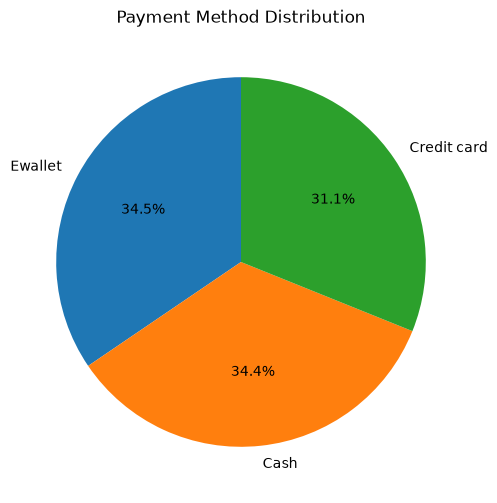

In [11]:
payment = df["Payment"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(payment,
        labels=payment.index,
        autopct="%1.1f%%",
        startangle=90)

plt.title("Payment Method Distribution")

plt.savefig("../visualization/payment_distribution.png")

plt.show()

In [12]:
      plt.figure(figsize=(8,5))

plt.hist(df["Rating"],
         bins=10)

plt.title("Customer Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Frequency")

plt.savefig("../visualization/rating_distribution.png")

plt.show()

IndentationError: unexpected indent (2219221488.py, line 1)

In [13]:
 plt.figure(figsize=(8,5))

plt.hist(df["Rating"], bins=10)

plt.title("Customer Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Frequency")

plt.savefig("../visualization/rating_distribution.png")

plt.show()

IndentationError: unexpected indent (301319721.py, line 1)

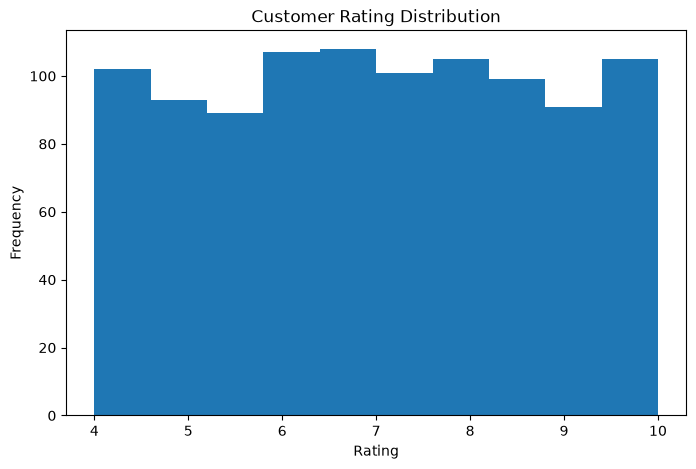

In [14]:
plt.figure(figsize=(8,5))

plt.hist(df["Rating"], bins=10)

plt.title("Customer Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Frequency")

plt.savefig("../visualization/rating_distribution.png")

plt.show()

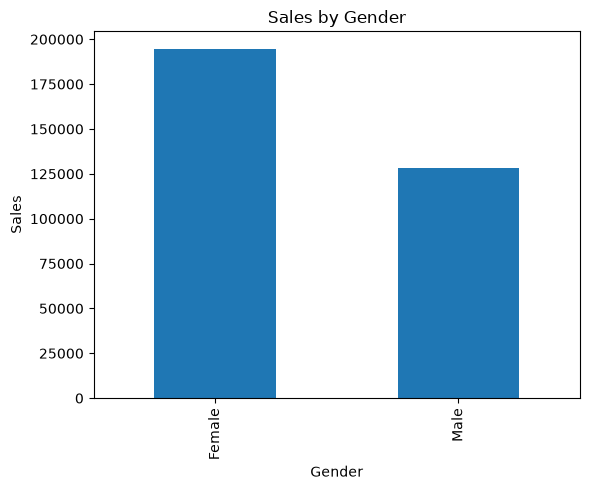

In [16]:
gender_sales = df.groupby("Gender")["Sales"].sum()

plt.figure(figsize=(6,5))

gender_sales.plot(kind="bar")

plt.title("Sales by Gender")
plt.xlabel("Gender")
plt.ylabel("Sales")

plt.tight_layout()

plt.savefig("../visualization/gender_sales.png")

plt.show()

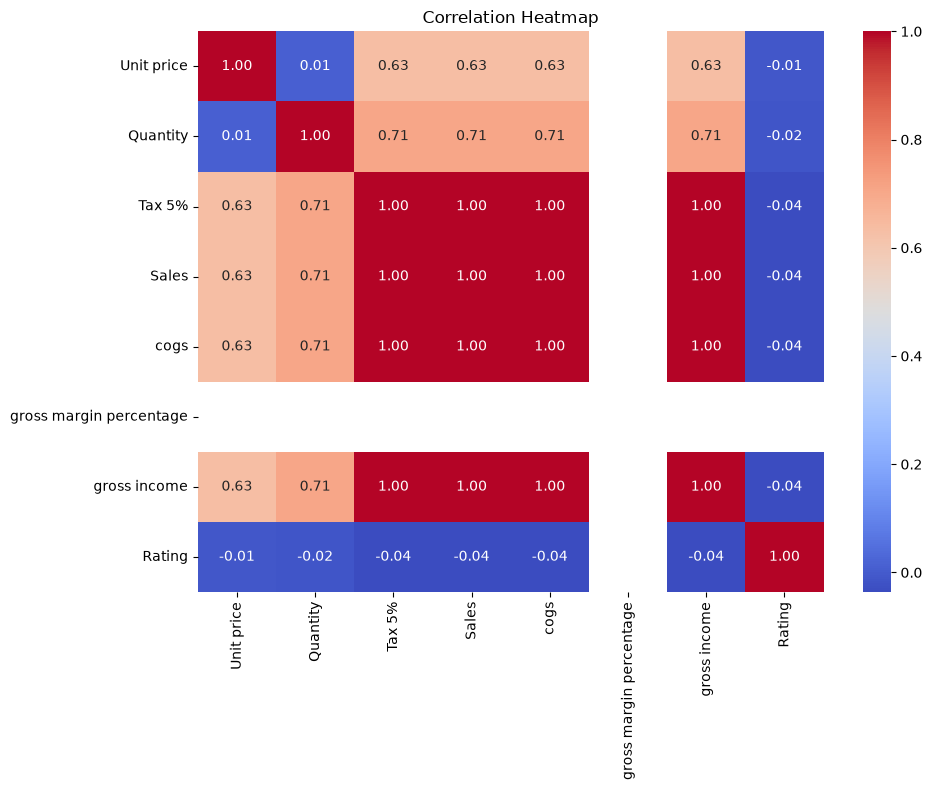

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

numeric_df = df.select_dtypes(include=["number"])

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.tight_layout()

plt.savefig("../visualization/correlation_heatmap.png")

plt.show()

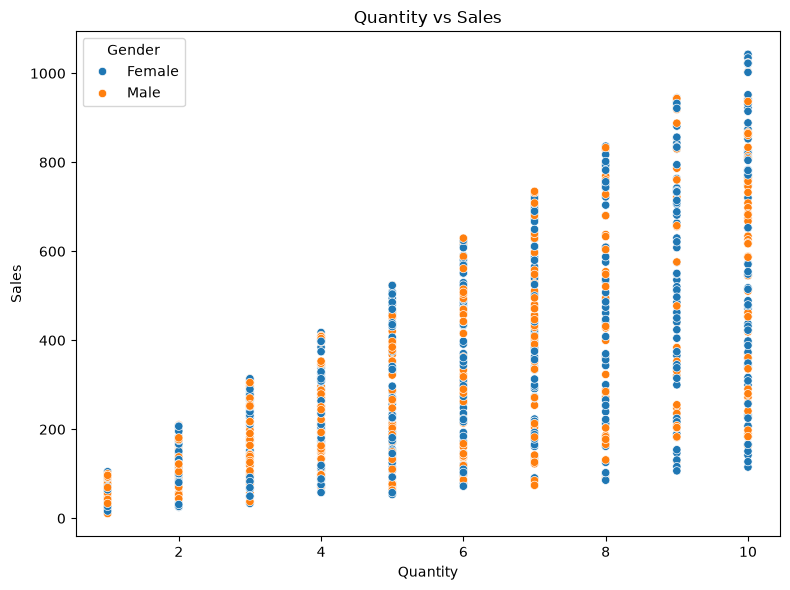

In [18]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="Quantity",
    y="Sales",
    hue="Gender"
)

plt.title("Quantity vs Sales")

plt.tight_layout()

plt.savefig("../visualization/quantity_vs_sales.png")

plt.show()

In [19]:
import plotly.express as px

fig = px.bar(
    df,
    x="Product line",
    y="Sales",
    color="Branch",
    title="Sales by Product Line"
)

fig.write_html("../visualization/interactive_dashboard.html")

fig.show()